In [1]:
# this file shows how to process 3D movement directly 
# without performing alignment 
# in this case, "match_points_gui.py" must be run once to match points to track
# but no other pre-processing steps should be required (other than system calibration)

In [1]:
from hsflfm.util import load_dictionary, save_dictionary, MetadataManager
from hsflfm.processing import StrikeProcessor 

import os 
from tqdm import tqdm 
import numpy as np 
from matplotlib import pyplot as plt 

In [2]:
def get_save_filename(specimen_number, strike_number, save_folder):
    if not os.path.exists(save_folder):
        os.mkdir(save_folder)
    spec_folder = save_folder + f"/{specimen_number}"
    if not os.path.exists(spec_folder):
        os.mkdir(spec_folder)
    filename = spec_folder + f"/strike_{int(strike_number)}_results.json"
    return filename

save_folder = "../results_20260526_B"

In [3]:
specimen = "20260526_B"
mm = MetadataManager(specimen) 
print(mm.match_points_filename)
match_points = load_dictionary(mm.match_points_filename)
results = {
    "match_points": match_points, 
    "specimen_number": specimen,
}

for strike_number in tqdm(mm.strike_numbers):
    results["strike_number"] = strike_number
    save_filename = get_save_filename(specimen, strike_number, save_folder)

    processor = StrikeProcessor(results.copy()) 
    processor.get_flow_vectors() 
    processor.run_regression() 
    result_info = processor.condense_info(displacements_only=True) 
    save_dictionary(result_info, save_filename)


C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260526_B/match_points


  0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\abhin\anaconda3\envs\hsflfm_cpu\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\abhin\anaconda3\envs\hsflfm_cpu\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\abhin\HighSpeedFLFM\hsflfm\processing\processing_functions.py:157: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\Convolution.cpp:1041.)
  output = conv1d(signal, self.filters, padding="same")
100%|██████████| 1/1 [00:02<00:00,  2.65s/it]


In [4]:
print(os.path.abspath(save_filename))

c:\Users\abhin\HighSpeedFLFM\results_20260526_B\20260526_B\strike_1_results.json


In [ ]:
# Verify match points are loaded correctly 
print(match_points.keys())
for cam, pts in match_points.items():
    print(cam, np.asarray(pts).shape)

dict_keys([0, 1, 2, 3, 4, 5])
0 (17, 5)
1 (17, 5)
2 (17, 5)
3 (17, 5)
4 (17, 5)
5 (17, 5)


In [ ]:
# XYZ start positions for points
print(processor.start_positions.shape)
print("NaNs in start_positions:", np.isnan(processor.start_positions).any())
print(processor.start_positions)

(17, 3)
NaNs in start_positions: False
[[3.89796043 4.98520711 0.02219974]
 [5.43477077 4.87563821 0.02220371]
 [6.8069201  5.20430506 0.02222437]
 [7.35578017 5.3138581  0.02224174]
 [7.52043873 5.47819671 0.02224769]
 [7.1911294  6.73814618 0.02223545]
 [6.53249346 6.29991136 0.02221031]
 [6.47760518 5.80689077 0.02220989]
 [6.14829304 7.17639593 0.02219307]
 [7.63022082 7.17638616 0.02225461]
 [5.76408867 4.05393232 0.02222955]
 [4.17239683 3.50613151 0.02226642]
 [2.41603749 4.27305491 0.02229943]
 [8.4534824  3.83477972 0.02227981]
 [2.03182547 6.84776079 0.02187501]
 [2.41602468 8.10769379 0.02179131]
 [2.36115283 3.56090177 0.02234594]]


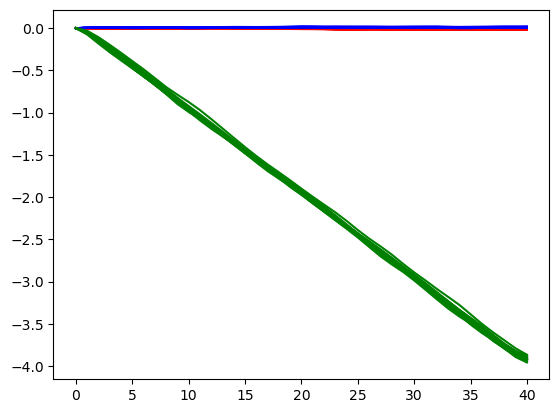

In [9]:
displacements = np.asarray(result_info["camera_point_displacements"])

for dim, color in enumerate(["red", "blue", "green"]):
    for p in displacements:
        plt.plot(p[:, dim], color=color)

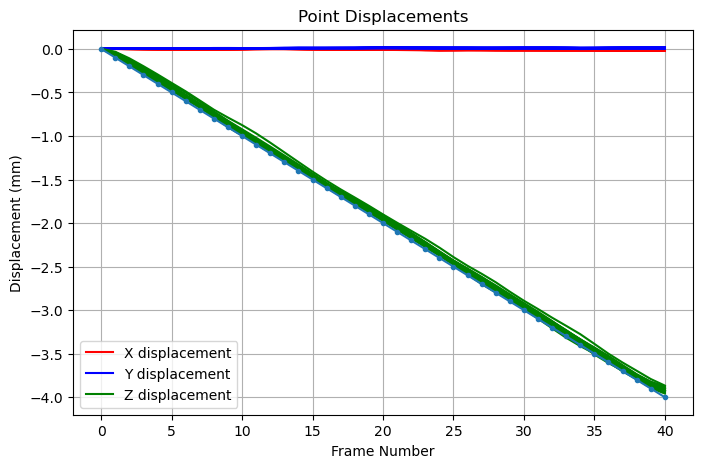

In [10]:
displacements = np.asarray(result_info["camera_point_displacements"])

labels = ["X displacement", "Y displacement", "Z displacement"]
colors = ["red", "blue", "green"]

x = np.arange(41)
y = -x * 0.1

plt.figure(figsize=(8, 5))

for dim, (color, label) in enumerate(zip(colors, labels)):
    for i, p in enumerate(displacements):
        if i == 0:
            plt.plot(p[:, dim], color=color, label=label)
        else:
            plt.plot(p[:, dim], color=color)


plt.plot(x, y, '.-')
plt.xlabel("Frame Number")
plt.ylabel("Displacement (mm)")
plt.title("Point Displacements")
plt.legend()
plt.grid(True)

plt.show()